<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Magnetic_phase_transitions_of_Terbium_(Tb)_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

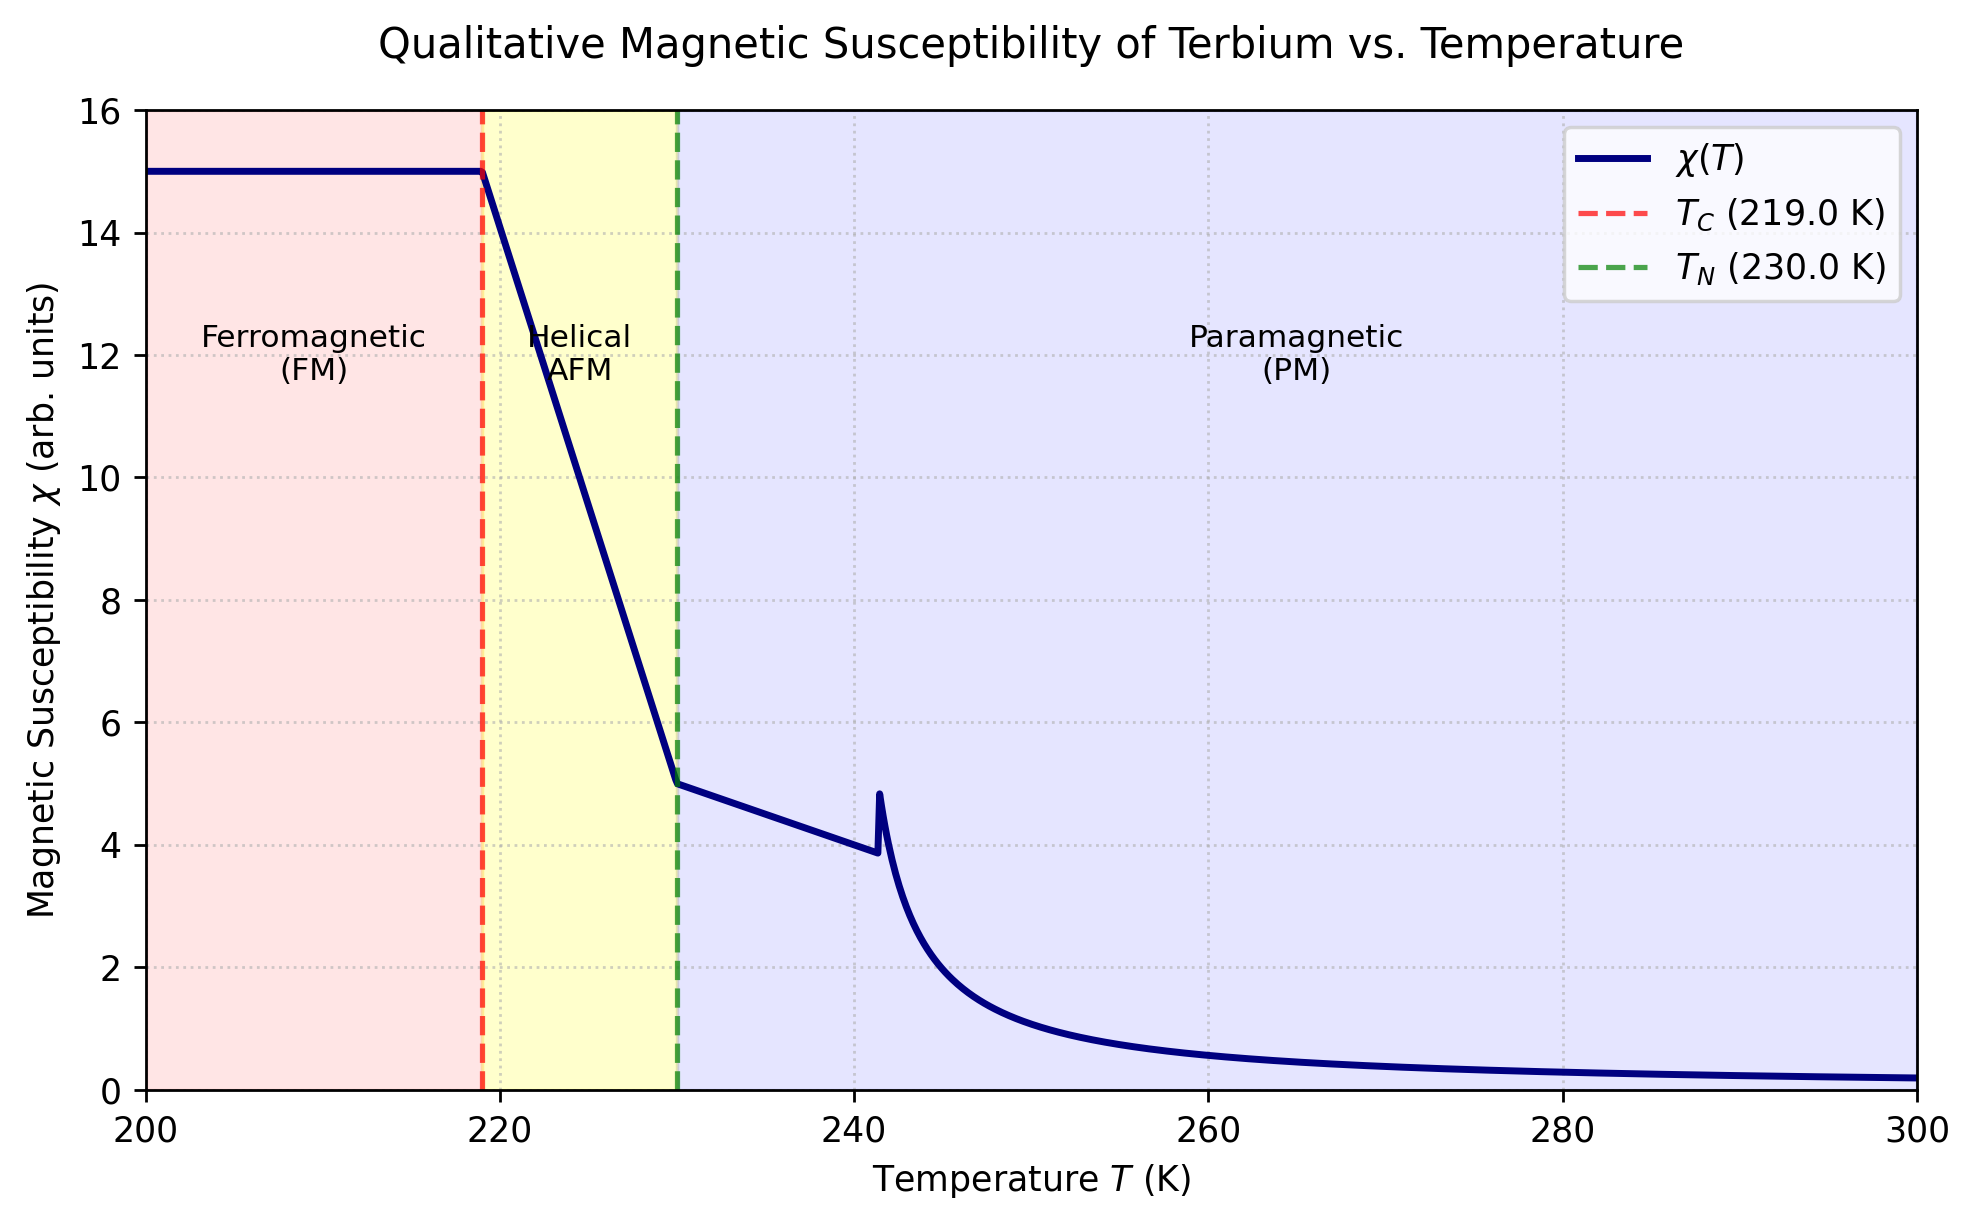

In [1]:
# !pip install numpy matplotlib

"""
Simulate and visualize the magnetic phase transitions of Terbium (Tb).

This module calculates a qualitative representation of magnetic susceptibility
versus temperature to demonstrate the transitions between Ferromagnetic,
Helical Antiferromagnetic, and Paramagnetic states.
"""

import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# CONTROL KNOBS
# ==============================================================================
T_C = 219.0          # Curie Temperature (K)
T_N = 230.0          # Neel Temperature (K)
T_MIN = 200.0        # Minimum simulation temperature (K)
T_MAX = 300.0        # Maximum simulation temperature (K)
POINTS = 1000        # Resolution of the simulation array
CURIE_CONST = 11.8   # Approximate Curie constant for Tb (emu K/mol)
THETA_P = 239.0      # Paramagnetic Curie Temperature / Weiss constant (K)
DPI_SETTING = 250    # Resolution of the rendered plot
# ==============================================================================

def generate_susceptibility(
    temperature: np.ndarray,
    t_c: float,
    t_n: float,
    c_const: float,
    theta_p: float
) -> np.ndarray:
    """
    Calculate the qualitative magnetic susceptibility for Terbium.

    Args:
        temperature (np.ndarray): Array of temperature values in Kelvin.
        t_c (float): Curie temperature.
        t_n (float): Neel temperature.
        c_const (float): Curie constant.
        theta_p (float): Paramagnetic Curie temperature.

    Returns:
        np.ndarray: Array of simulated magnetic susceptibility values.
    """
    susceptibility = np.zeros_like(temperature)

    for idx, t in enumerate(temperature):
        if t < t_c:
            # Ferromagnetic regime: Susceptibility is very high/divergent
            # Using a simplified high constant for visualization purposes
            susceptibility[idx] = 15.0

        elif t_c <= t <= t_n:
            # Helical Antiferromagnetic regime: Susceptibility drops from a peak
            # Interpolating a sharp drop between T_C and T_N
            fraction = (t - t_c) / (t_n - t_c)
            susceptibility[idx] = 15.0 - (fraction * 10.0)

        else:
            # Paramagnetic regime: Follows Curie-Weiss law
            # A small offset prevents division by zero near the asymptote
            denominator = (t - theta_p) if (t - theta_p) > 0.5 else 0.5
            susceptibility[idx] = c_const / denominator

            # Ensure continuity at the boundary for the plot
            if susceptibility[idx] > 5.0:
                susceptibility[idx] = 5.0 - (t - t_n) * 0.1

    return susceptibility

def plot_terbium_phases() -> None:
    """Configure and render the plot of Terbium magnetic phases."""
    # Enforce Colab rendering settings based on user requirements
    plt.rcParams['figure.dpi'] = DPI_SETTING

    # Generate data
    temperatures = np.linspace(T_MIN, T_MAX, POINTS)
    chi = generate_susceptibility(temperatures, T_C, T_N, CURIE_CONST, THETA_P)

    # Construct the visualization
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(temperatures, chi, color='navy', linewidth=2, label=r'$\chi(T)$')

    # Annotate phase transition boundaries
    ax.axvline(x=T_C, color='red', linestyle='--', alpha=0.7, label=rf'$T_C$ ({T_C} K)')
    ax.axvline(x=T_N, color='green', linestyle='--', alpha=0.7, label=rf'$T_N$ ({T_N} K)')

    # Define phase regions visually
    ax.axvspan(T_MIN, T_C, color='red', alpha=0.1)
    ax.axvspan(T_C, T_N, color='yellow', alpha=0.2)
    ax.axvspan(T_N, T_MAX, color='blue', alpha=0.1)

    # Label the regions
    ax.text((T_MIN + T_C)/2, 12, 'Ferromagnetic\n(FM)',
            ha='center', va='center', fontsize=9)
    ax.text((T_C + T_N)/2, 12, 'Helical\nAFM',
            ha='center', va='center', fontsize=9)
    ax.text((T_N + T_MAX)/2, 12, 'Paramagnetic\n(PM)',
            ha='center', va='center', fontsize=9)

    # Format the axes
    ax.set_title('Qualitative Magnetic Susceptibility of Terbium vs. Temperature', pad=15)
    ax.set_xlabel('Temperature $T$ (K)')
    ax.set_ylabel(r'Magnetic Susceptibility $\chi$ (arb. units)')
    ax.set_xlim(T_MIN, T_MAX)
    ax.set_ylim(0, 16)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')

    # Render explicitly in the Colab output cell
    plt.tight_layout()
    plt.show()

# Execute the plotting routine
if __name__ == '__main__':
    plot_terbium_phases()